In [1]:
!pip install joblib
  

Defaulting to user installation because normal site-packages is not writeable


In [53]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression   

In [54]:
df=pd.read_csv("ahd.csv")
print(df.head())
print(df.tail())

   Zip Code      Price  Beds  Baths  Living Space                Address  \
0     10013  3999000.0     2      3          1967      74 GRAND ST APT 3   
1     10013  3999000.0     2      3          1967      74 GRAND ST APT 3   
2     10014  1650000.0     1      1           718  140 CHARLES ST APT 4D   
3     10014   760000.0     3      2          1538            38 JONES ST   
4     10014  1100000.0     1      1           600   81 BEDFORD ST APT 3F   

       City     State  Zip Code Population  Zip Code Density    County  \
0  New York  New York                29563           20967.9  New York   
1  New York  New York                29563           20967.9  New York   
2  New York  New York                29815           23740.9  New York   
3  New York  New York                29815           23740.9  New York   
4  New York  New York                29815           23740.9  New York   

   Median Household Income  Latitude  Longitude  
0                 370046.0  40.72001  -74.00472 

In [55]:
df.dtypes

Zip Code                     int64
Price                      float64
Beds                         int64
Baths                        int64
Living Space                 int64
Address                        str
City                           str
State                          str
Zip Code Population          int64
Zip Code Density           float64
County                         str
Median Household Income    float64
Latitude                   float64
Longitude                  float64
dtype: object

In [56]:
df.columns

Index(['Zip Code', 'Price', 'Beds', 'Baths', 'Living Space', 'Address', 'City',
       'State', 'Zip Code Population', 'Zip Code Density', 'County',
       'Median Household Income', 'Latitude', 'Longitude'],
      dtype='str')

In [57]:
df.shape

(39981, 14)

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39981 entries, 0 to 39980
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Zip Code                 39981 non-null  int64  
 1   Price                    39981 non-null  float64
 2   Beds                     39981 non-null  int64  
 3   Baths                    39981 non-null  int64  
 4   Living Space             39981 non-null  int64  
 5   Address                  39981 non-null  str    
 6   City                     39981 non-null  str    
 7   State                    39981 non-null  str    
 8   Zip Code Population      39981 non-null  int64  
 9   Zip Code Density         39981 non-null  float64
 10  County                   39981 non-null  str    
 11  Median Household Income  39979 non-null  float64
 12  Latitude                 39981 non-null  float64
 13  Longitude                39981 non-null  float64
dtypes: float64(5), int64(5), str(4)
m

In [59]:
df.describe()

,Zip Code,Price,Beds,Baths,Living Space,Zip Code Population,Zip Code Density,Median Household Income,Latitude,Longitude
count,39981.000000,3.998100e+04,39981.000000,39981.000000,39981.000000,39981.000000,39981.000000,39979.000000,39981.000000,39981.000000
mean,64833.391336,6.227771e+05,3.171682,2.466572,1901.522723,37726.201996,2379.412483,110837.259861,36.435668,-98.080576
std,25614.601116,9.469793e+05,1.308796,1.323042,1211.307257,18672.647445,2946.574792,47309.055715,4.446862,15.061145
min,10013.000000,1.800000e+03,1.000000,1.000000,2.000000,0.000000,0.000000,27475.000000,25.729830,-122.826870
25%,40215.000000,2.650000e+05,3.000000,2.000000,1200.000000,24465.000000,902.400000,76640.000000,33.239850,-111.636310
50%,74136.000000,3.999000e+05,3.000000,2.000000,1639.000000,35049.000000,1588.700000,100405.000000,36.166620,-96.839680
75%,85730.000000,6.749900e+05,4.000000,3.000000,2265.000000,46816.000000,2736.800000,135075.000000,39.283090,-85.656980
max,98199.000000,3.800000e+07,54.000000,66.000000,74340.000000,116469.000000,58289.600000,900203.000000,47.742370,-73.704510


In [60]:
df.drop('Address', axis=1, inplace=True)

In [61]:
df

,Zip Code,Price,Beds,Baths,Living Space,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
0,10013,3999000.0,2,3,1967,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
1,10013,3999000.0,2,3,1967,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
2,10014,1650000.0,1,1,718,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
3,10014,760000.0,3,2,1538,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
4,10014,1100000.0,1,1,600,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39976,98199,2495000.0,4,4,3380,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39977,98199,2295000.0,4,4,2878,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39978,98199,950000.0,3,2,1380,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39979,98199,425000.0,2,1,856,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223


In [62]:
le_city=LabelEncoder()
df['City'] = le_city.fit_transform(df['City'])
le_state=LabelEncoder()
df['State'] = le_state.fit_transform(df['State'])
le_county=LabelEncoder()
df['County'] = le_county.fit_transform(df['County'])

In [63]:
df.dtypes

Zip Code                     int64
Price                      float64
Beds                         int64
Baths                        int64
Living Space                 int64
City                         int64
State                        int64
Zip Code Population          int64
Zip Code Density           float64
County                       int64
Median Household Income    float64
Latitude                   float64
Longitude                  float64
dtype: object

In [64]:
df.isnull()

,Zip Code,Price,Beds,Baths,Living Space,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39976,False,False,False,False,False,False,False,False,False,False,False,False,False
39977,False,False,False,False,False,False,False,False,False,False,False,False,False
39978,False,False,False,False,False,False,False,False,False,False,False,False,False
39979,False,False,False,False,False,False,False,False,False,False,False,False,False


In [65]:
df.isnull().sum()

Zip Code                   0
Price                      0
Beds                       0
Baths                      0
Living Space               0
City                       0
State                      0
Zip Code Population        0
Zip Code Density           0
County                     0
Median Household Income    2
Latitude                   0
Longitude                  0
dtype: int64

In [66]:
df=df.dropna()

In [67]:
df.isnull().sum()

Zip Code                   0
Price                      0
Beds                       0
Baths                      0
Living Space               0
City                       0
State                      0
Zip Code Population        0
Zip Code Density           0
County                     0
Median Household Income    0
Latitude                   0
Longitude                  0
dtype: int64

In [68]:
df.shape

(39979, 13)

{'whiskers': [<matplotlib.lines.Line2D at 0x26da1459590>,
 'caps': [<matplotlib.lines.Line2D at 0x26da1459810>,
 'boxes': [<matplotlib.patches.PathPatch at 0x26da1459450>],
 'medians': [<matplotlib.lines.Line2D at 0x26da1459a90>],
 'fliers': [<matplotlib.lines.Line2D at 0x26da1459bd0>],
 'means': []}

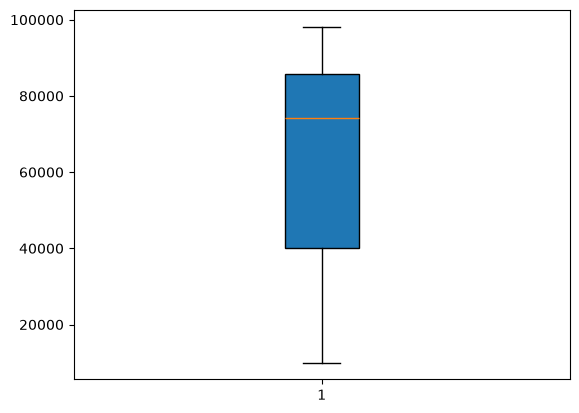

In [69]:
plt.boxplot(df['Zip Code'],patch_artist=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x26da146bed0>,
 'caps': [<matplotlib.lines.Line2D at 0x26da1428190>,
 'boxes': [<matplotlib.patches.PathPatch at 0x26da146bd90>],
 'medians': [<matplotlib.lines.Line2D at 0x26da1428410>],
 'fliers': [<matplotlib.lines.Line2D at 0x26da1428550>],
 'means': []}

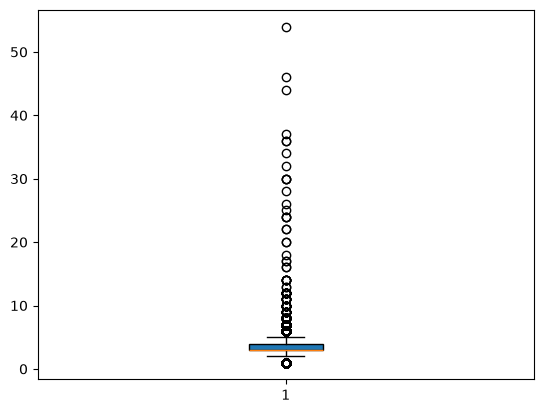

In [70]:
plt.boxplot(df['Beds'],patch_artist=True)

In [71]:
Q1=df['Beds'].quantile(0.25)
Q3=df['Beds'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

upper_index=np.where(df['Beds']>=upper)[0]
lower_index=np.where(df['Beds']<=lower)[0]

df.drop(index=upper_index,inplace=True)
df.drop(index=lower_index,inplace=True)

In [72]:
df.reset_index(inplace=True)
df.drop('index', axis=1, inplace=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x26da13ef110>,
 'caps': [<matplotlib.lines.Line2D at 0x26da13ef390>,
 'boxes': [<matplotlib.patches.PathPatch at 0x26da13eefd0>],
 'medians': [<matplotlib.lines.Line2D at 0x26da13ef610>],
 'fliers': [<matplotlib.lines.Line2D at 0x26da13ef750>],
 'means': []}

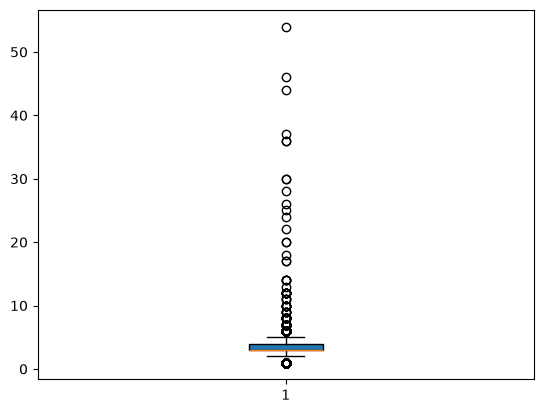

In [73]:
plt.boxplot(df['Beds'],patch_artist=True)

In [74]:
#do same forr all others

In [75]:
correlation=df.corr()
correlation

,Zip Code,Price,Beds,Baths,Living Space,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
Zip Code,1.000000,0.125097,0.011802,0.000582,0.035757,0.077741,-0.217021,-0.021886,-0.078308,-0.050806,0.163074,-0.060571,-0.939429
Price,0.125097,1.000000,0.267996,0.461948,0.513491,0.082237,-0.156834,-0.047239,0.171522,0.028002,0.438247,-0.059595,-0.183207
Beds,0.011802,0.267996,1.000000,0.673388,0.637747,-0.035441,0.038629,0.051121,-0.118691,0.000192,0.033711,-0.057118,0.008965
Baths,0.000582,0.461948,0.673388,1.000000,0.749686,-0.028531,0.016268,-0.010417,-0.053371,-0.036437,0.259726,-0.108341,0.003834
Living Space,0.035757,0.513491,0.637747,0.749686,1.000000,-0.028318,0.038698,-0.057754,-0.095256,-0.017322,0.248057,-0.068600,-0.012496
City,0.077741,0.082237,-0.035441,-0.028531,-0.028318,1.000000,-0.115661,-0.032042,0.094100,0.309668,0.128917,0.125031,-0.174476
State,-0.217021,-0.156834,0.038629,0.016268,0.038698,-0.115661,1.000000,0.037095,-0.150812,0.084642,-0.119102,0.036462,0.345900
Zip Code Population,-0.021886,-0.047239,0.051121,-0.010417,-0.057754,-0.032042,0.037095,1.000000,0.107954,-0.055781,-0.119906,-0.094175,-0.021845
Zip Code Density,-0.078308,0.171522,-0.118691,-0.053371,-0.095256,0.094100,-0.150812,0.107954,1.000000,-0.012950,0.167817,0.189067,-0.001547
County,-0.050806,0.028002,0.000192,-0.036437,-0.017322,0.309668,0.084642,-0.055781,-0.012950,1.000000,0.029773,-0.007591,0.050554


<Axes: >

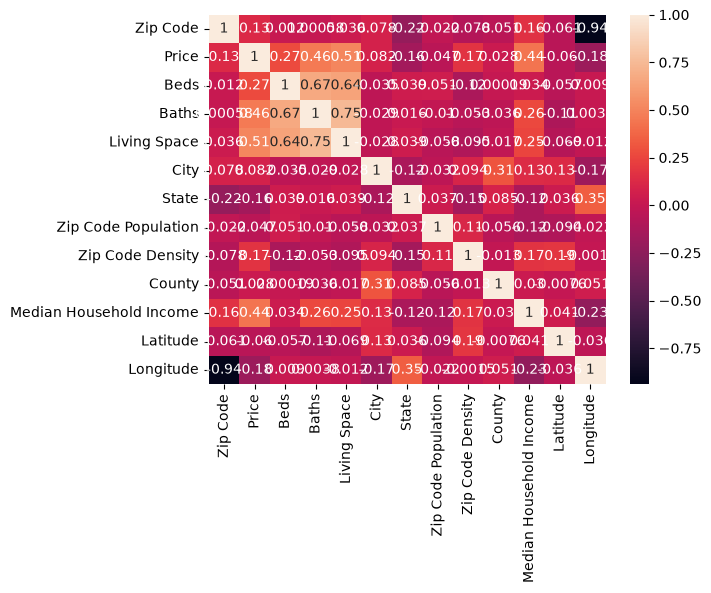

In [76]:
sns.heatmap(correlation, annot=True)